# GRM with Stan

Graded Response Model (Samejima, 1969) — polytomous IRT for ordered categories.

## Cumulative response probability

$$
P^*(u_{ij} \geq k \mid \theta_i) = \frac{1}{1 + \exp\bigl(-a_j (\theta_i - b_{jk})\bigr)}
\quad k = 1, \ldots, K-1
$$

## Category probability

$$
P(u_{ij} = k \mid \theta_i) = P^*(u_{ij} \geq k) - P^*(u_{ij} \geq k+1)
$$

with $P^*(u_{ij} \geq 0) = 1$ and $P^*(u_{ij} \geq K) = 0$.

- $\theta_i$: ability of respondent $i$
- $a_j > 0$: discrimination of item $j$
- $b_{j1} < b_{j2} < \cdots < b_{j,K-1}$: ordered threshold parameters of item $j$

## Priors

$$
\theta_i \sim \mathcal{N}(0,1), \quad
a_j \sim \text{LogNormal}(0, 0.5), \quad
b_{jk} \sim \mathcal{N}(0, 1) \text{ (ordered constraint enforced by Stan)}
$$

In [1]:
import nest_asyncio
nest_asyncio.apply()

import numpy as np
import matplotlib.pyplot as plt
import stan
import arviz as az

## Data Generation

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items
K = 4    # ordered response categories: 0, 1, 2, 3

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
b_true = np.sort(rng.normal(0, 1, (J, K - 1)), axis=1)  # (J, K-1) ordered

# P*(Y >= k) for k=1,...,K-1 — shape (N, J, K-1)
eta = a_true[None, :, None] * (theta_true[:, None, None] - b_true[None, :, :])
cum_p = 1 / (1 + np.exp(-eta))

# Category probabilities — shape (N, J, K)
probs = np.concatenate([
    1 - cum_p[:, :, 0:1],
    cum_p[:, :, :-1] - cum_p[:, :, 1:],
    cum_p[:, :, -1:],
], axis=2)

# Sample responses via inverse CDF
u = rng.uniform(size=(N, J, 1))
Y = (u > np.cumsum(probs, axis=2)).sum(axis=2).astype(int)  # (N, J)

print(f"Response matrix shape: {Y.shape}")
print(f"Category counts: {np.bincount(Y.ravel())}")
print(f"True a range: [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b[:,0] range: [{b_true[:,0].min():.2f}, {b_true[:,0].max():.2f}]")

Response matrix shape: (100, 20)
Category counts: [696 294 294 716]
True a range: [0.42, 2.23]
True b[:,0] range: [-2.13, 0.41]


## Stan Model

`ordered[K-1]` in Stan automatically enforces $b_{j1} < b_{j2} < \cdots < b_{j,K-1}$.

In [3]:
model_code = """
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=2> K;
  array[N, J] int<lower=1, upper=K> Y;  // 1-indexed for categorical()
}
parameters {
  vector[N] theta;
  vector<lower=0>[J] a;
  array[J] ordered[K-1] b;
}
model {
  theta ~ normal(0, 1);
  a ~ lognormal(0, 0.5);
  for (j in 1:J) {
    b[j] ~ normal(0, 1);
  }

  for (i in 1:N) {
    for (j in 1:J) {
      vector[K-1] cp;  // P*(Y >= k) for k=1,...,K-1
      vector[K] p;

      for (k in 1:(K-1)) {
        cp[k] = inv_logit(a[j] * (theta[i] - b[j][k]));
      }

      p[1] = 1 - cp[1];
      for (k in 2:(K-1)) {
        p[k] = cp[k-1] - cp[k];
      }
      p[K] = cp[K-1];

      Y[i, j] ~ categorical(p);
    }
  }
}
"""

## Compile and Sample

Stan's categorical distribution is 1-indexed, so we pass `Y + 1`.

In [4]:
%%time
data_dict = {"N": N, "J": J, "K": K, "Y": (Y + 1).tolist()}

posterior = stan.build(model_code, data=data_dict, random_seed=42)
fit = posterior.sample(num_chains=4, num_samples=1000, num_warmup=1000, random_seed=0)

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7623f6ae61c0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7623f6ae61c0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7623f6ae61c0> is already entered
Exception in callback Task.__step()
h

CPU times: user 1.57 s, sys: 475 ms, total: 2.04 s
Wall time: 29.5 s


## Results

In [5]:
idata = az.from_pystan(fit)
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.56,0.15,0.30,0.83,0.00,0.00,1991.54,2554.26,1.0
a[1],1.53,0.34,0.92,2.18,0.01,0.01,2279.03,2593.67,1.0
a[2],0.86,0.20,0.51,1.23,0.00,0.00,2328.92,2591.02,1.0
a[3],1.54,0.35,0.94,2.21,0.01,0.01,2261.03,2491.27,1.0
a[4],0.67,0.18,0.34,0.99,0.00,0.00,2046.74,2924.54,1.0
...,...,...,...,...,...,...,...,...,...
"b[18, 1]",0.34,0.13,0.09,0.59,0.00,0.00,2040.34,2636.63,1.0
"b[18, 2]",1.45,0.22,1.05,1.86,0.00,0.00,1999.15,2616.53,1.0
"b[19, 0]",-0.28,0.33,-0.93,0.30,0.01,0.01,2947.96,2479.53,1.0
"b[19, 1]",0.12,0.30,-0.43,0.71,0.00,0.01,4439.79,2673.28,1.0


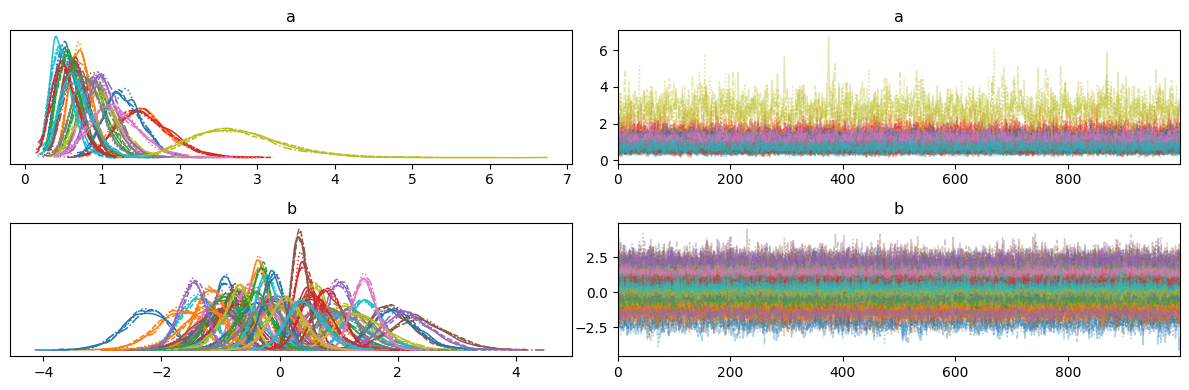

In [6]:
az.plot_trace(idata, var_names=["a", "b"], compact=True)
plt.tight_layout()
plt.show()

## Comparison: Estimated vs True Parameters

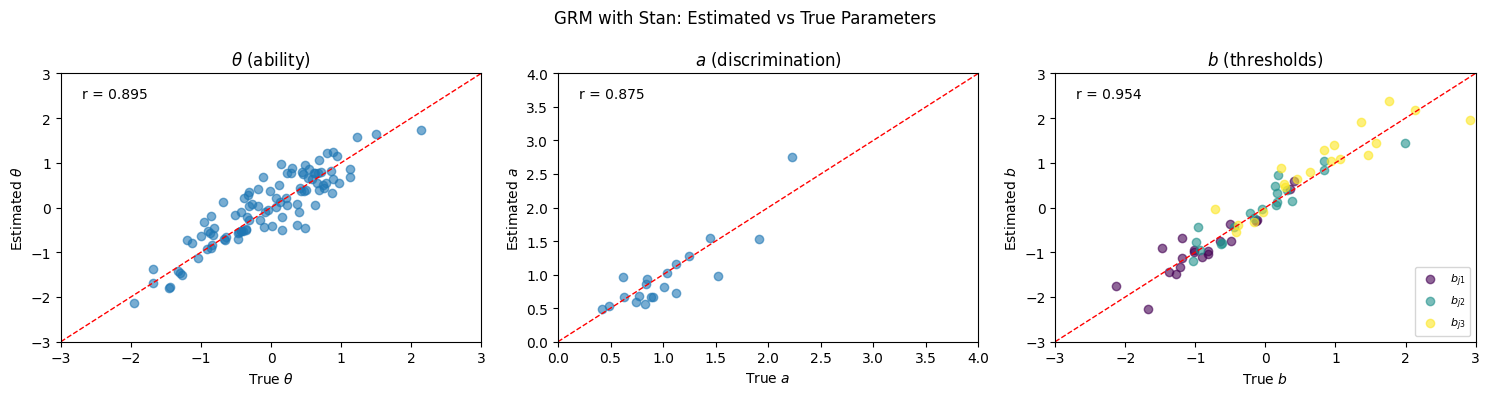

In [7]:
theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values           # (J,)
b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values           # (J, K-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# theta
axes[0].scatter(theta_true, theta_est, alpha=0.6)
axes[0].plot([-3, 3], [-3, 3], "r--", lw=1)
axes[0].set(xlim=(-3, 3), ylim=(-3, 3),
            xlabel=r"True $\theta$", ylabel=r"Estimated $\theta$",
            title=r"$\theta$ (ability)")
axes[0].text(0.05, 0.95, f"r = {np.corrcoef(theta_true, theta_est)[0,1]:.3f}",
             transform=axes[0].transAxes, va="top")

# a
axes[1].scatter(a_true, a_est, alpha=0.6)
axes[1].plot([0, 4], [0, 4], "r--", lw=1)
axes[1].set(xlim=(0, 4), ylim=(0, 4),
            xlabel=r"True $a$", ylabel=r"Estimated $a$",
            title=r"$a$ (discrimination)")
axes[1].text(0.05, 0.95, f"r = {np.corrcoef(a_true, a_est)[0,1]:.3f}",
             transform=axes[1].transAxes, va="top")

# b — all J*(K-1) threshold pairs, colored by threshold index
colors = plt.cm.viridis(np.linspace(0, 1, K - 1))
for k in range(K - 1):
    axes[2].scatter(b_true[:, k], b_est[:, k], alpha=0.6,
                    color=colors[k], label=f"$b_{{j{k+1}}}$")
axes[2].plot([-3, 3], [-3, 3], "r--", lw=1)
axes[2].set(xlim=(-3, 3), ylim=(-3, 3),
            xlabel=r"True $b$", ylabel=r"Estimated $b$",
            title=r"$b$ (thresholds)")
axes[2].legend(fontsize=8)
b_corr = np.corrcoef(b_true.ravel(), b_est.ravel())[0, 1]
axes[2].text(0.05, 0.95, f"r = {b_corr:.3f}",
             transform=axes[2].transAxes, va="top")

plt.suptitle("GRM with Stan: Estimated vs True Parameters")
plt.tight_layout()
plt.show()